# To test your installation first try to import the frappe package

In [1]:
from frappe import Frappe


/opt/anaconda3/envs/testFrap/lib/python3.9/site-packages/frappe


# Define all inputs needed by frappe


In [2]:
#currently frappe is set up only to deal with X-Shooter spectra, which are split between a UVB,VIS and NIR arm. 
#Frappe therefore takes the directory of these three files as an input. Only the NIR file is optional.
#Later updates will allow for other spectra to be fitted.
dirSpec = '/Users/rikclaes/Documents/Work/ChaI/CHX18N/XS/'
fileUVB = 'flux_CHX18N_ep2_uvb.fits'
fileVIS = 'flux_CHX18N_ep2_vis_tell.fits'
fileNIR = 'flux_CHX18N_ep2_nir_tell.fits'
# Give the name of the target. This name will be used to name the output folder and table entry
obj_in = 'CHX18N_ep2'
# The distance to the target needs to be set here.
dist = 192
# Give the output directory. A folder with all outputs will be created here. 
#If you run multiple fits a table summarizing the output of each fit can also be created here
dirOut = '/Users/rikclaes/python/functions/MyFitter/FrappePackage/tests/'
# now set the list of Av and SpT values that you wish to fit for
# the SpT values are given in spectral code, where the Value 0 corresponds to SpT = M0, 2 to SpT =M2 and so on
# A Spectral code of -1 corresponds to K7, -2 to K6 and so on.
# The code -9 corresponds to spt = G9
# Both arrays are optional inputs for frappe
# It is however recomended to use an input based on literature values as otherwise,
# the entire spt range will be used and an av range between Av = 0 and 2
# fitting for the entire range will increase the runtime. 
Av = [0.7,0.8,0.9,1.0,1.1,1.2,1.3,1.4,1.5,1.6]
spt = [-1.5,-2,-2.5,-3,-3.5,-4,-4.5,-5,-5.5,-6.0,-7.0]



# Now we can run frappe!
this will take a few minutes for a grid this size

In [3]:
# Here we used the inputs defined in the previous cell
# there the following optional inputs
# fitsTab = False(default) if true the directories should refer to fits tables rather than the fits files used by default
# Rv = 3.1(default) sets the Rv value of the cardelli extinction law used in the best fit determination
# perAA = False(default) if true assumes the fluxes of the input spectra are in units of [erg/s/cm**2/AA] if false: [erg/s/cm**2/nm]
f2 = Frappe.Fit(dirSpec+fileUVB,
                 dirSpec+fileVIS,
                 dirSpec+fileNIR,
                 obj_in,
                 dist,
                 dirOut,
                 spt = spt,
                 Av = Av,
                 fitsTab =False)

here
/Users/rikclaes/python/functions/MyFitter/FrappePackage/tests/CHX18N_ep2_2025-05-15_17.13.15
CHX18N_ep2
[0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6]
[0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6]
You have given a selection of spectral types
working_dir   /opt/anaconda3/envs/testFrap/lib/python3.9/site-packages/frappe/models_grid/


2025-05-15 17:13:16,981	INFO worker.py:1888 -- Started a local Ray instance.
2025-05-15 17:13:16,995	INFO packaging.py:576 -- Creating a file package for local module '/opt/anaconda3/envs/testFrap/lib/python3.9/site-packages/frappe/FrappeHelper/'.
2025-05-15 17:13:17,005	INFO packaging.py:368 -- Pushing file package 'gcs://_ray_pkg_21965433c6ef740f.zip' (0.28MiB) to Ray cluster...
2025-05-15 17:13:17,007	INFO packaging.py:381 -- Successfully pushed file package 'gcs://_ray_pkg_21965433c6ef740f.zip'.


(main_process pid=79732) /opt/anaconda3/envs/testFrap/lib/python3.9/site-packages/frappe
(main_process pid=79733) /opt/anaconda3/envs/testFrap/lib/python3.9/site-packages/frappe
(main_process pid=79734) /opt/anaconda3/envs/testFrap/lib/python3.9/site-packages/frappe
(main_process pid=79732) NOT POSSIBLE
(main_process pid=79732) initial H already negative
(main_process pid=79732) NOT POSSIBLE
(main_process pid=79732) initial H already negative
(main_process pid=79732) NOT POSSIBLE
(main_process pid=79732) initial H already negative
(main_process pid=79732) NOT POSSIBLE
(main_process pid=79732) initial H already negative
(main_process pid=79732) NOT POSSIBLE
(main_process pid=79732) initial H already negative
(main_process pid=79732) NOT POSSIBLE
(main_process pid=79732) initial H already negative
(main_process pid=79732) NOT POSSIBLE
(main_process pid=79732) initial H already negative
(main_process pid=79732) NOT POSSIBLE
(main_process pid=79732) initial H already negative
(main_process

Now, if all went well, we can see some some of the best fit properties found by frappe. This is however not very practical.

# So lets store some outputs!

In [4]:
# there are three options to do so
# the first writes an extensive rapport to a file saved in a folder created for this frappe run
f2.resultsToFile()
# the sec writes a summary of the best fit results to the output dir.
#if Fileout = None(Default) places a table in dirOut, otherwise will write a line in FileOut
f2.addEntryToTable(FileOut = None)
# the third writes the values for all sampled location in the grid to a csv file
f2.writeCSV()

NUMBER OF LINES IN THE FILE:  3981
BAD LINES:
9
GOOD LINES:
3972
NUMBER OF LINES IN THE FILE:  3981
BAD LINES:
9
GOOD LINES:
3972
MA PERCHE???????????
MA PERCHE???????????


# Now lets have a look at the best fit solution

NUMBER OF LINES IN THE FILE:  3981
BAD LINES:
9
GOOD LINES:
3972


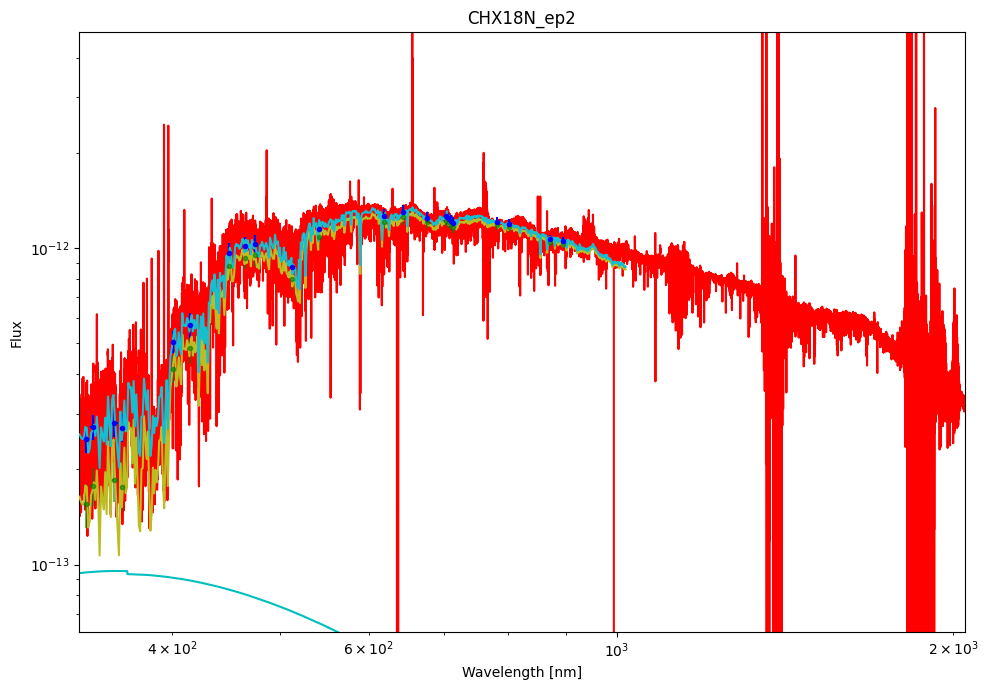

NUMBER OF LINES IN THE FILE:  3981
BAD LINES:
9
GOOD LINES:
3972


<Figure size 640x480 with 0 Axes>

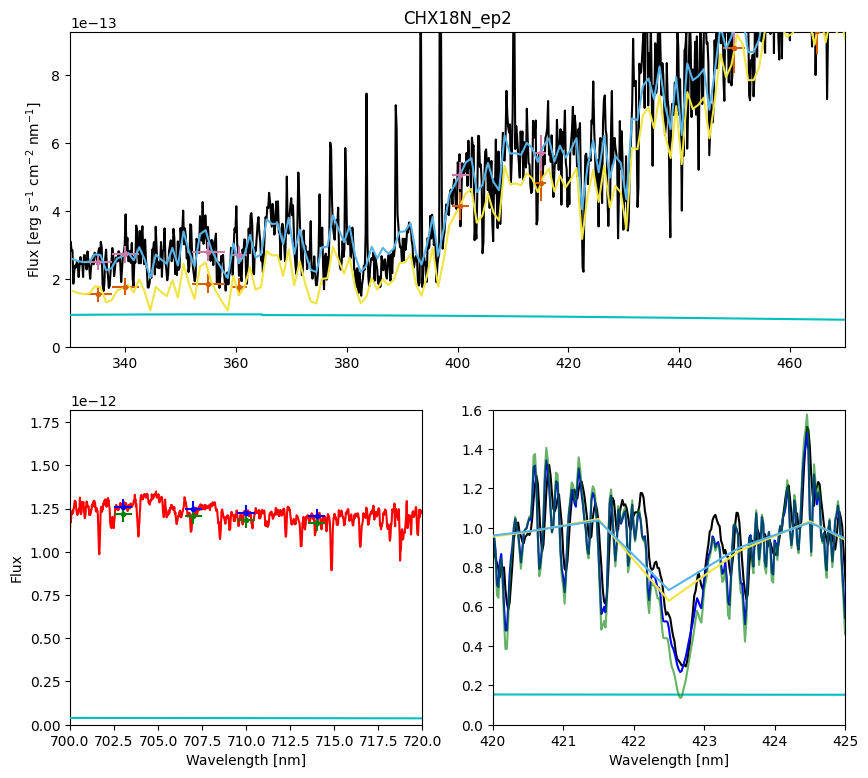

NUMBER OF LINES IN THE FILE:  3981
BAD LINES:
9
GOOD LINES:
3972


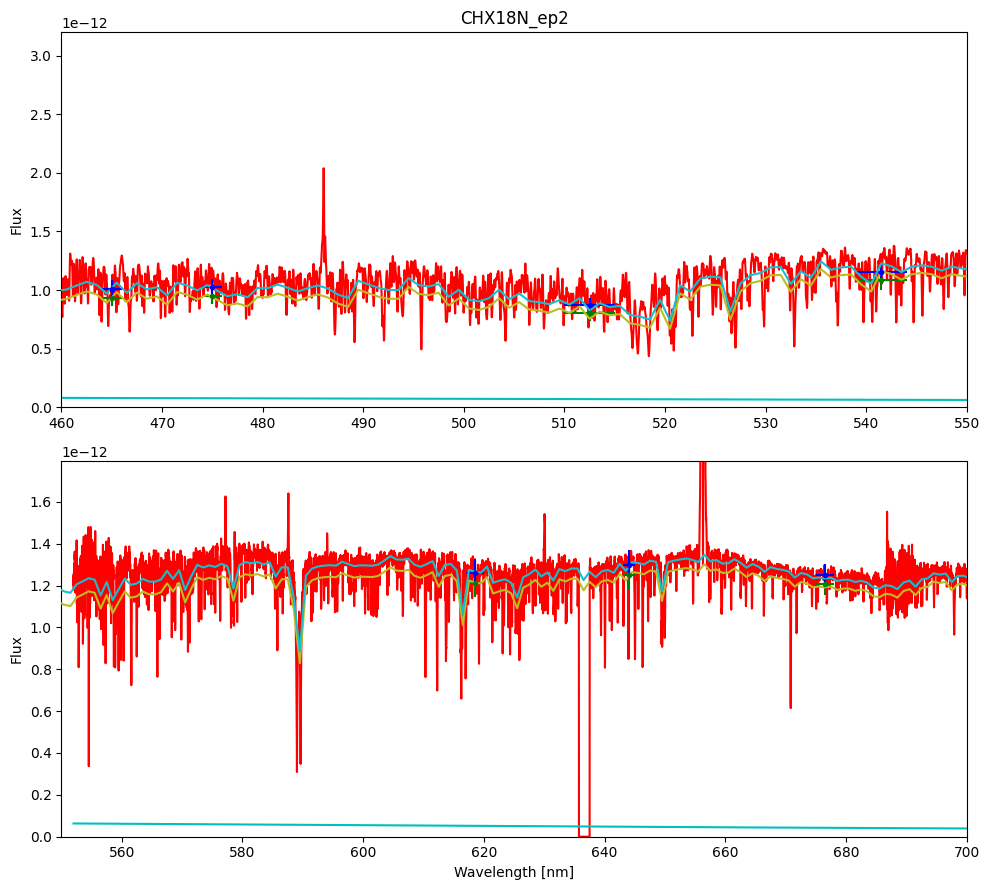

NUMBER OF LINES IN THE FILE:  3981
BAD LINES:
9
GOOD LINES:
3972


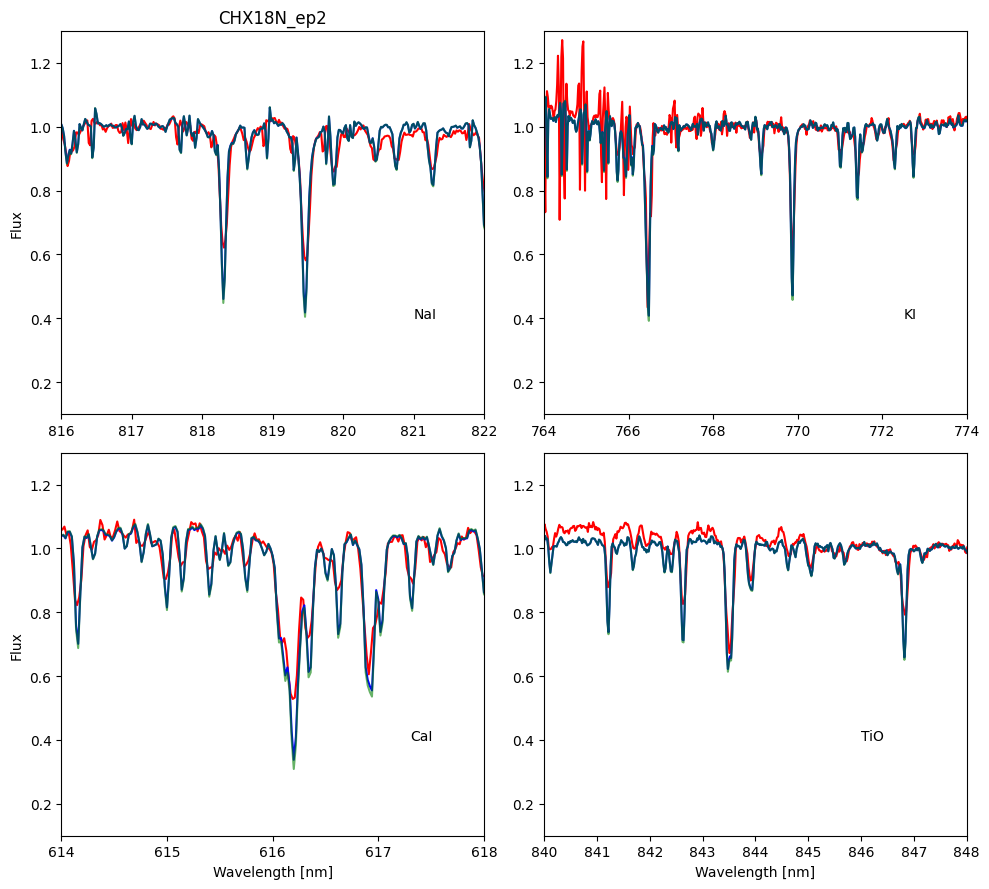

In [5]:
# If you want to interact with the plots simple run: 
# %matplotlib qt


# There are four built in methods to examine the best fit solution
# All of the generated plots will be stored to the file associated with this run.

# The first plots the intire wavelength range of the observed X-shooter spectra
# options:
# CLIII = False(Default)If false uses an interpolated slab model, if True uses a Class III spectrum of the nearest SpT
# smooth = False(Default) If true smoothing will be applied to the observed spectrum for clarity
# close = False(Default) If true closes the plot imediatly
f2.plotAll(CLIII = False,smooth = False, close = False)

# The second plots some key regions of interest.
#These regions are:
# The region around the Balmer jump
# The ~710nm TiO feature, which is a critical spectral type constraint for stars later than ~K6
# The ~422nm Ca absorbtion line, which is a great indicator to see how well the veiling of the observed spectra is reproduced.
# IT IS KEY TO CHECK THIS LAST FEATURE AS WILL BE SHOWN IN THE NEXT EXAMPLE!
# close = False(Default) If true closes the plot imediatly
f2.plotRegFit(close = False)
# The second plots some regions of interest in the Paschen continuum.
# In particular the top pannel shows A feature at ~510nm that is usefull to constrain the spectal type of early K stars
# CLIII = False(Default)If false uses an interpolated slab model, if True uses a Class III spectrum of the nearest SpT
# close = False(Default) If true closes the plot imediatly
f2.plotPaschen(CLIII =False,close = False)
# The second plots some regions of interest in the Paschen continuum.
# close = False(Default) If true closes the plot imediatly
f2.plotVeil(close =False)

## In this case the spectra appears to be reproduced well

## We can also have a look how the sollutions look as a function of Av and SpT to see if there are degeneracies.

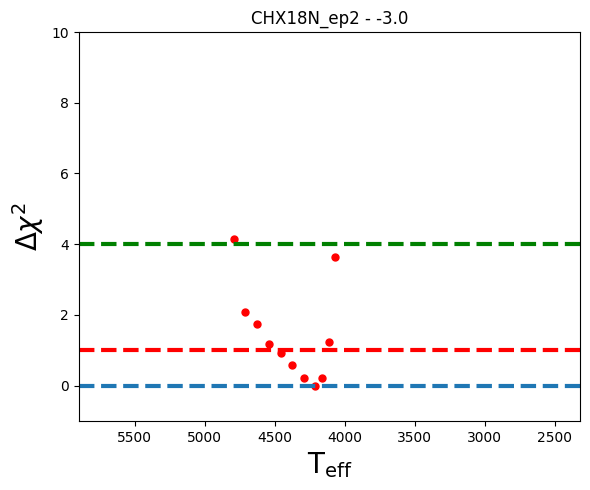

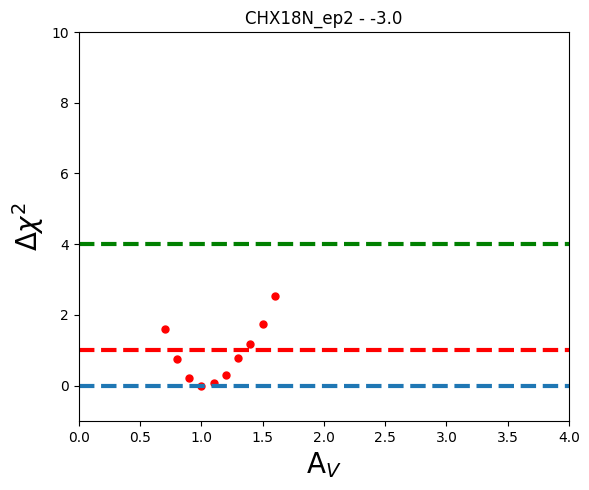

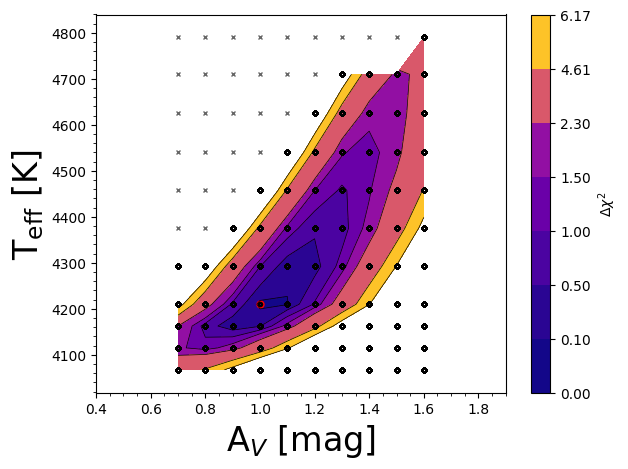

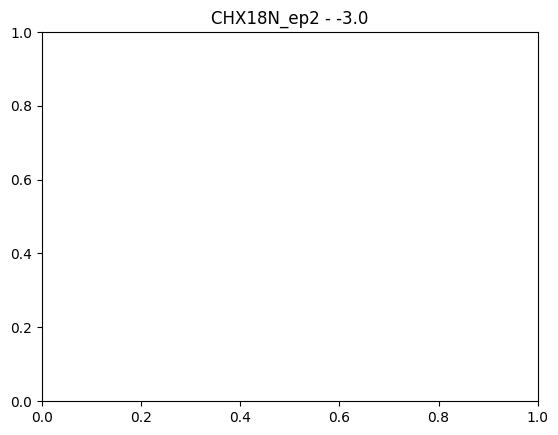

In [6]:
# Three plot options are provided:
# The first plot the difference in chi**2_like of the overal best solutions (delta Chi**2) to the best solution at different effective temperatures
f2.Chi2SpT()
# The first plot the difference in chi**2_like of the overal best solutions (delta Chi**2) to the best solution at different Av
f2.Chi2Av()
# finally we can also plot a delta Chi**2 map in terms of both Teff and Av
# these plot only inlcudes the best solution at a given SpT and Av combination.
# They therefore do not indicate a posterior probability and can NOT be used to estimate the uncertainty on these parameters
# their main goal is to detect and explore degenerate solutions!
f2.Chi2AvAndSpT()

## Here it can be seen that there is a clear best solution!
The X symbols on the final plot indicate combinations of Av and Teff(SpT) for which no physical solution could be found

# Now lets explore a more difficult example: 

here
/Users/rikclaes/python/functions/MyFitter/FrappePackage/tests/GOTau_2025-05-15_17.27.58
GOTau
[0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6]
[0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6]
You have given a selection of spectral types
working_dir   /opt/anaconda3/envs/testFrap/lib/python3.9/site-packages/frappe/models_grid/


2025-05-15 17:28:01,036	INFO worker.py:1888 -- Started a local Ray instance.
2025-05-15 17:28:01,055	INFO packaging.py:576 -- Creating a file package for local module '/opt/anaconda3/envs/testFrap/lib/python3.9/site-packages/frappe/FrappeHelper/'.
2025-05-15 17:28:01,066	INFO packaging.py:368 -- Pushing file package 'gcs://_ray_pkg_21965433c6ef740f.zip' (0.28MiB) to Ray cluster...
2025-05-15 17:28:01,069	INFO packaging.py:381 -- Successfully pushed file package 'gcs://_ray_pkg_21965433c6ef740f.zip'.


(main_process pid=79793) /opt/anaconda3/envs/testFrap/lib/python3.9/site-packages/frappe
(main_process pid=79797) /opt/anaconda3/envs/testFrap/lib/python3.9/site-packages/frappe
(main_process pid=79794) /opt/anaconda3/envs/testFrap/lib/python3.9/site-packages/frappe
(main_process pid=79798) /opt/anaconda3/envs/testFrap/lib/python3.9/site-packages/frappe
(main_process pid=79796) /opt/anaconda3/envs/testFrap/lib/python3.9/site-packages/frappe
(main_process pid=79795) /opt/anaconda3/envs/testFrap/lib/python3.9/site-packages/frappe
(main_process pid=79792) /opt/anaconda3/envs/testFrap/lib/python3.9/site-packages/frappe
(main_process pid=79791) /opt/anaconda3/envs/testFrap/lib/python3.9/site-packages/frappe
(main_process pid=79790) /opt/anaconda3/envs/testFrap/lib/python3.9/site-packages/frappe
Execution time: 129.76847314834595  seconds
    
    
---------------
---------------
BEST CHI SQUARED:  14.527277934213735
 
PARAMETERS OF BEST FIT: ClassIII = 2.0 , Av= 1.2 , T= 6000 , Ne= 1e+11 , 

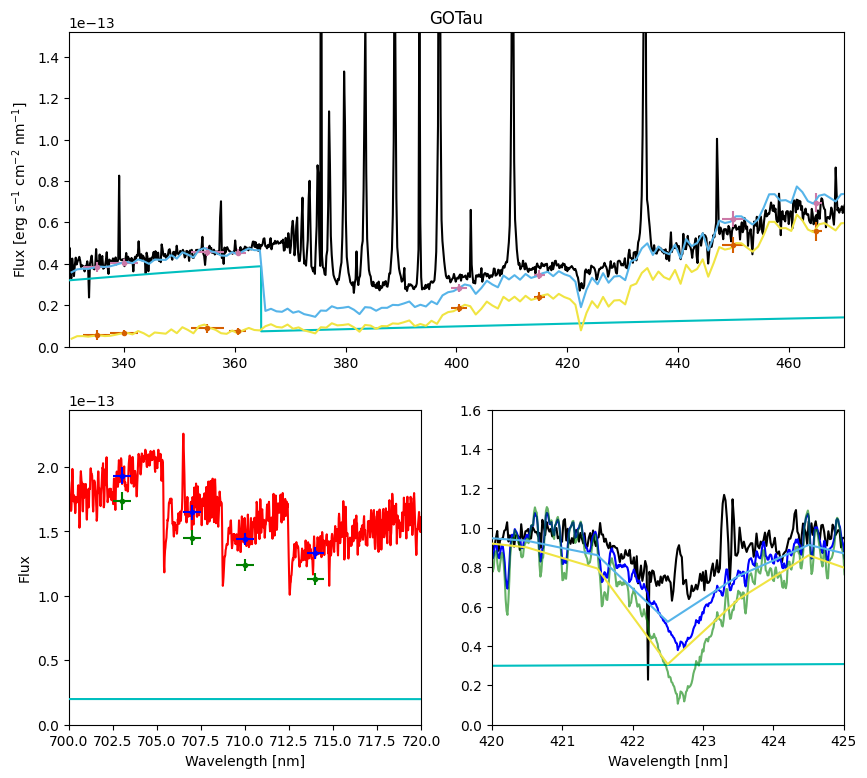

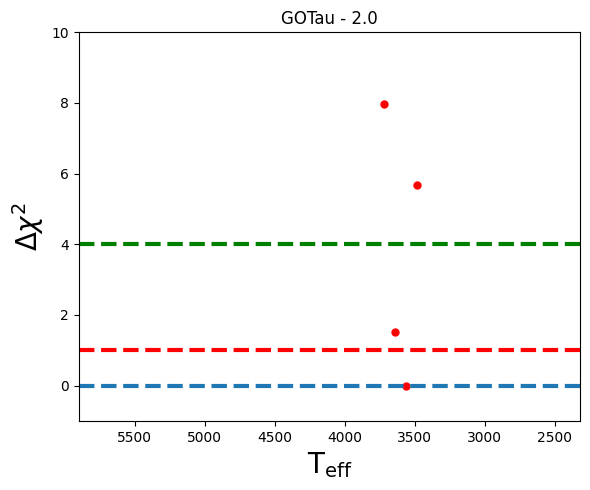

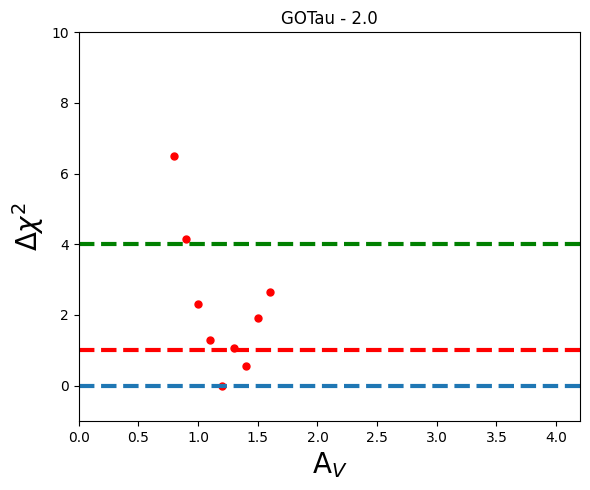

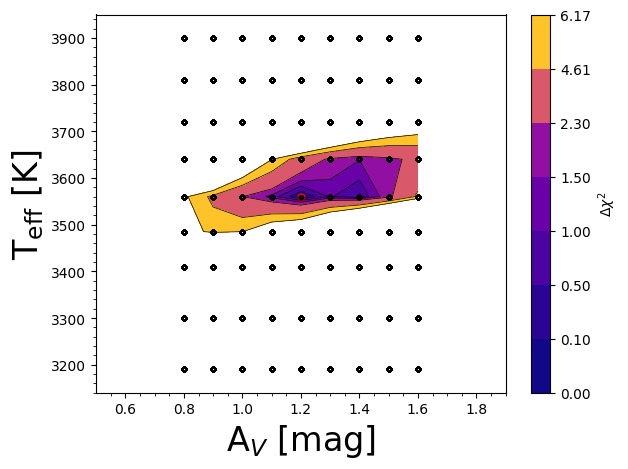

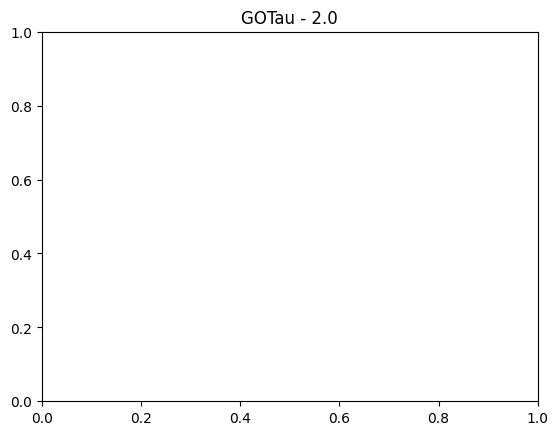

NUMBER OF LINES IN THE FILE:  3981
BAD LINES:
9
GOOD LINES:
3972


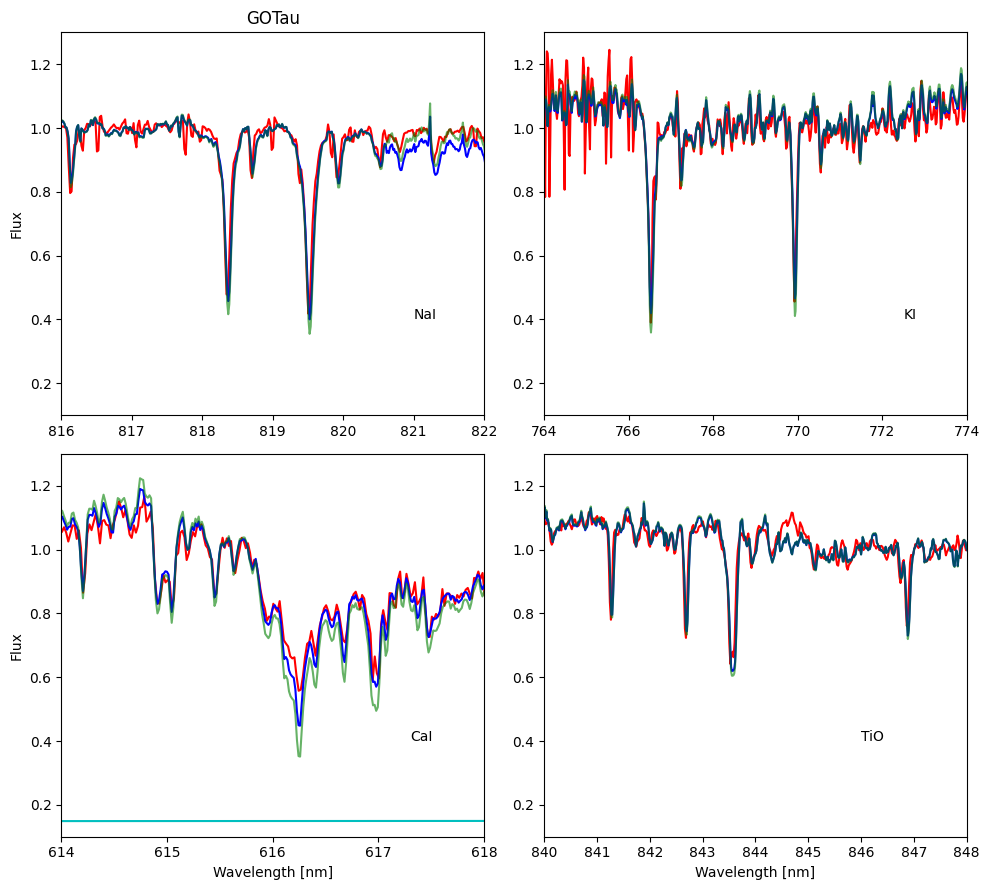

In [7]:
dirSpec = '/Users/rikclaes/python/functions/MyFitter/FrappePackage/ExampleSpectra/GOTau/' 
fileUVB = 'flux_GOTau_uvb.fits'
fileVIS = 'flux_GOTau_vis_tell.fits'
fileNIR = 'flux_GOTau_nir_tell.fits'
# Give the name of the target. This name will be used to name the output folder and table entry
obj_in = 'GOTau'
# The distance to the target needs to be set here.
dist = 192
dirOut = '/Users/rikclaes/python/functions/MyFitter/FrappePackage/tests/'
Av = [0.8,0.9,1.0,1.1,1.2,1.3,1.4,1.5,1.6]
spt = [0.0,0.5,1.0,1.5,2,2.5,3,3.5,4]

f2 = Frappe.Fit(dirSpec+fileUVB,
                 dirSpec+fileVIS,
                 dirSpec+fileNIR,
                 obj_in,
                 dist,
                 dirOut,
                 spt = spt,
                 Av = Av,
                 fitsTab =False)

f2.plotRegFit(close = False)
f2.Chi2SpT()
f2.Chi2Av()
f2.Chi2AvAndSpT()
f2.plotVeil(close =False)

## Here it is clear that the Ca line at ~422nm is poorly reproduced. 
## At the same time there appears to be a secondary minimum in Delta as a function of Av at Av = 1.4.
## So lets try this solution:

here
/Users/rikclaes/python/functions/MyFitter/FrappePackage/tests/GOTau_2025-05-15_17.30.16
GOTau
[1.4]
[1.4]
You have given a selection of spectral types
working_dir   /opt/anaconda3/envs/testFrap/lib/python3.9/site-packages/frappe/models_grid/


2025-05-15 17:30:18,255	INFO worker.py:1888 -- Started a local Ray instance.
2025-05-15 17:30:18,277	INFO packaging.py:576 -- Creating a file package for local module '/opt/anaconda3/envs/testFrap/lib/python3.9/site-packages/frappe/FrappeHelper/'.
2025-05-15 17:30:18,291	INFO packaging.py:368 -- Pushing file package 'gcs://_ray_pkg_21965433c6ef740f.zip' (0.28MiB) to Ray cluster...
2025-05-15 17:30:18,294	INFO packaging.py:381 -- Successfully pushed file package 'gcs://_ray_pkg_21965433c6ef740f.zip'.


(main_process pid=79832) /opt/anaconda3/envs/testFrap/lib/python3.9/site-packages/frappe
(main_process pid=79830) /opt/anaconda3/envs/testFrap/lib/python3.9/site-packages/frappe
(main_process pid=79829) /opt/anaconda3/envs/testFrap/lib/python3.9/site-packages/frappe
(main_process pid=79833) /opt/anaconda3/envs/testFrap/lib/python3.9/site-packages/frappe
(main_process pid=79831) /opt/anaconda3/envs/testFrap/lib/python3.9/site-packages/frappe
Execution time: 15.154124975204468  seconds
    
    
---------------
---------------
BEST CHI SQUARED:  15.09391599916743
 
PARAMETERS OF BEST FIT: ClassIII = 2.0 , Av= 1.4 , T= 6500 , Ne= 1e+12 , tau= 5
NORMALIZATION CONSTANTS FOR THE BEST FIT: H= [1.24042514e-21] , K= [2.08931114e-13]
---------------
---------------
NUMBER OF LINES IN THE FILE:  3981
BAD LINES:
9
GOOD LINES:
3972


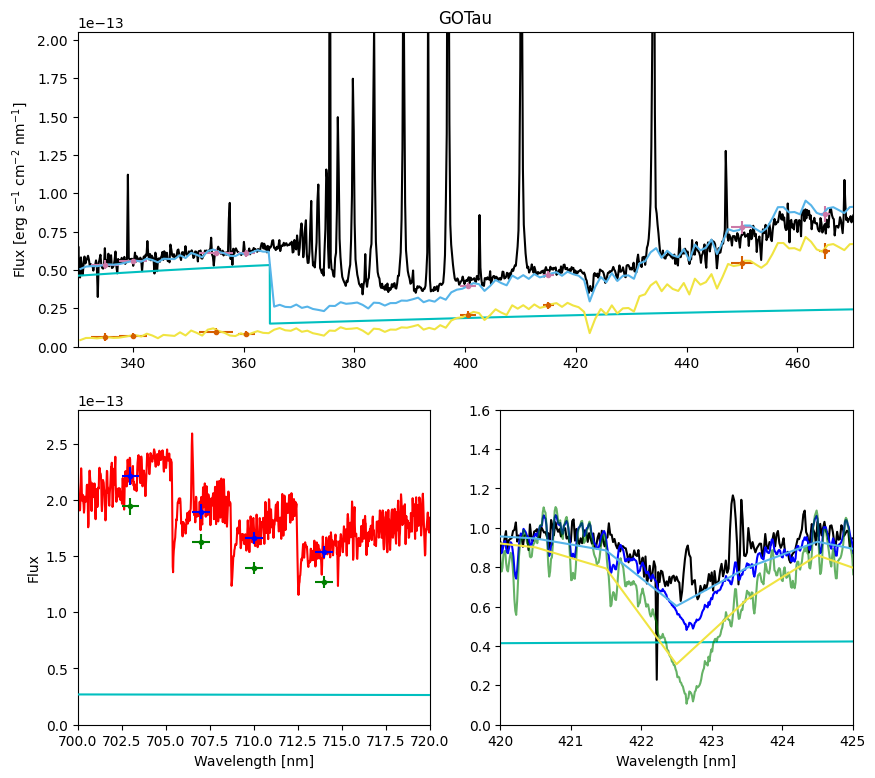

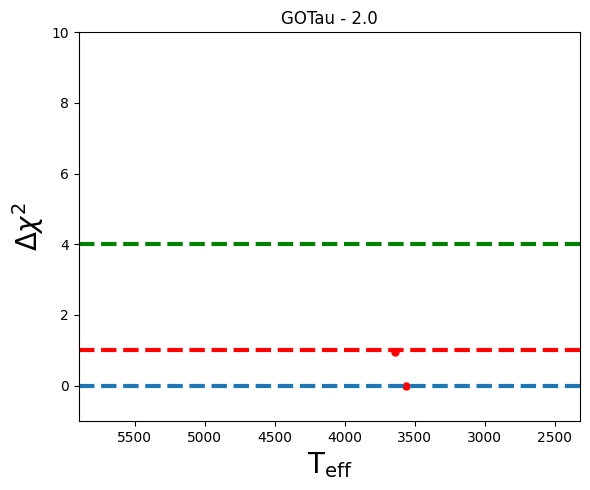

NUMBER OF LINES IN THE FILE:  3981
BAD LINES:
9
GOOD LINES:
3972


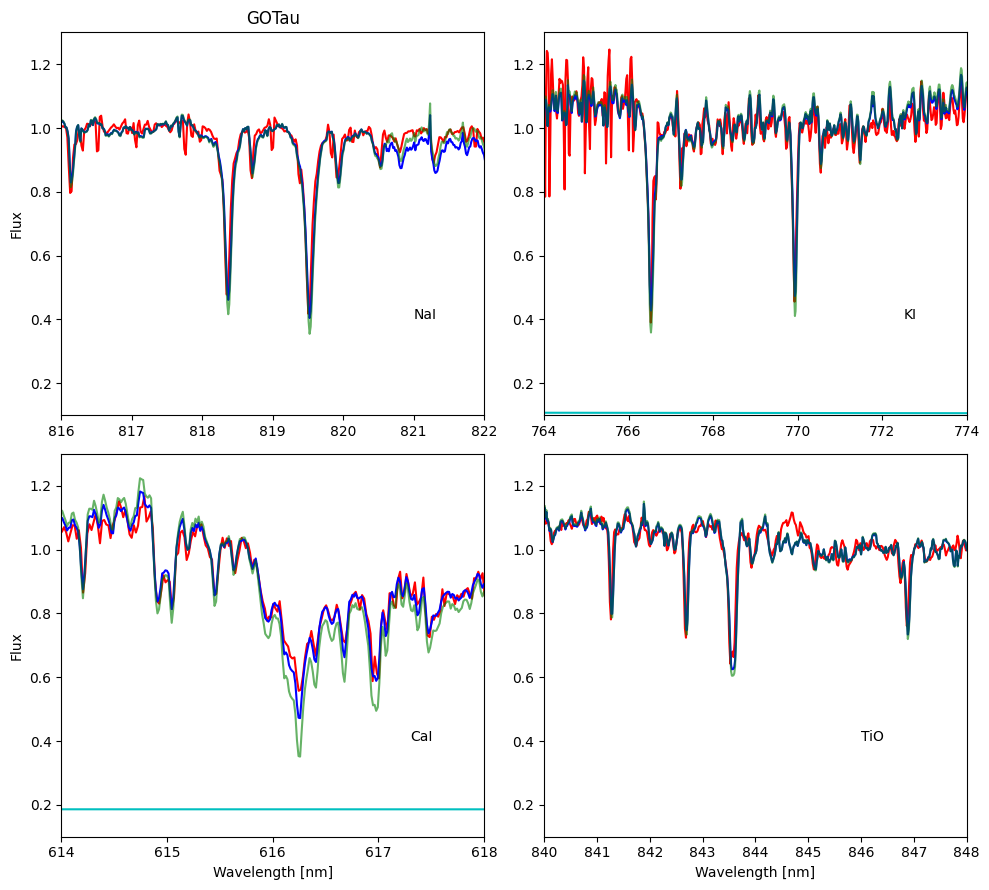

In [8]:
dirSpec = '/Users/rikclaes/python/functions/MyFitter/FrappePackage/ExampleSpectra/GOTau/' 
fileUVB = 'flux_GOTau_uvb.fits'
fileVIS = 'flux_GOTau_vis_tell.fits'
fileNIR = 'flux_GOTau_nir_tell.fits'
from frappe import Frappe
# Give the name of the target. This name will be used to name the output folder and table entry
obj_in = 'GOTau'
# The distance to the target needs to be set here.
dist = 192
dirOut = '/Users/rikclaes/python/functions/MyFitter/FrappePackage/tests/'
Av = [1.4]
spt = [1.0,1.5,2,2.5,3]

f2 = Frappe.Fit(dirSpec+fileUVB,
                 dirSpec+fileVIS,
                 dirSpec+fileNIR,
                 obj_in,
                 dist,
                 dirOut,
                 spt = spt,
                 Av = Av,
                 fitsTab =False)

f2.plotRegFit(close = False)
f2.Chi2SpT()
f2.Chi2Av()
f2.Chi2AvAndSpT()
f2.plotVeil(close =False)

# This clearly improved how well the veiling of this line is reproduced and highlights the importance of checking these plots!

# To imporove this issue one can also try to use FrappeEQW,
## which takes into account the equivalent width of a number of emmission lines in the best fit determination  
# FappeEQW is untested, please use at your own discression!!
FrappeEQW will first measure the equivalent widths of a number of lines in the observed spectra.
To do this an interactive window will be opened.
Here it is important to eliminate emission lines present in the observed spectra as the slab models used in Frappe can not reproduce these.
This can be done with the following controls:
* leftclick - select a point
* enter - interpolate over the region between two selected points, exactly two points need to be selected for this to work. a red spectrum that
* n - ignore the displayed region, to be used when no clear absorption line is detected at the center of the window
* w - adopt the plotted red spectrum for the eqw computation

The interpolation step can be repeated as often as the user wants

In [9]:
from frappe import FrappeEQW
%matplotlib qt 
# needs to be used for functionality
dirSpec = '/Users/rikclaes/Documents/Work/StructuredSources/Spectra/' 
fileUVB = 'UVB/flux_GOTau_uvb.fits'
fileVIS = 'VIS/flux_GOTau_vis_tell.fits'
fileNIR = 'NIR/flux_GOTau_nir_tell.fits'
# Give the name of the target. This name will be used to name the output folder and table entry
obj_in = 'GOTau'
# The distance to the target needs to be set here.
dist = 192
dirOut = '/Users/rikclaes/python/functions/MyFitter/FrappePackage/tests/'
Av = [1.1,1.2,1.3,1.4,1.5,1.6,1.7,1.8]
spt = [0.0,0.5,1.0,1.5,2,2.5,3,3.5,4]

f2 = FrappeEQW.Fit(dirSpec+fileUVB,
                 dirSpec+fileVIS,
                 dirSpec+fileNIR,
                 obj_in,
                 dist,
                 dirOut,
                 spt = spt,
                 Av = Av,
                 fitsTab =False)
f2.plotAll()
f2.plotRegFit(close = False)
f2.Chi2SpT()
f2.Chi2Av()
f2.Chi2AvAndSpT()
f2.plotVeil(close =False)

here
/Users/rikclaes/python/functions/MyFitter/FrappePackage/tests/GOTau_2025-05-15_17.30.36
GOTau
[1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8]
[1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8]
You have given a selection of spectral types
[ 298.92  298.94  298.96 ... 1019.96 1019.98 1020.  ] 422.0816288371488
[ 298.92  298.94  298.96 ... 1019.96 1019.98 1020.  ] 422.2695434443288
[ 298.92  298.94  298.96 ... 1019.96 1019.98 1020.  ] 422.5555004552549
[ 298.92  298.94  298.96 ... 1019.96 1019.98 1020.  ] 422.84962766649323
[ 298.92  298.94  298.96 ... 1019.96 1019.98 1020.  ] 423.21728668054106
[ 298.92  298.94  298.96 ... 1019.96 1019.98 1020.  ] 423.5604350936524
[ 298.92  298.94  298.96 ... 1019.96 1019.98 1020.  ] 423.9362643080125
[ 298.92  298.94  298.96 ... 1019.96 1019.98 1020.  ] 424.32843392299685
Here
[0.07866462]
the absorption line at466.7nm does not have an eqw measurement at some of the considered SpTs and will therefore not be used in the best fit determination
the absorption line at495.7nm

2025-05-15 17:31:32,188	INFO worker.py:1888 -- Started a local Ray instance.
2025-05-15 17:31:32,198	INFO packaging.py:576 -- Creating a file package for local module '/opt/anaconda3/envs/testFrap/lib/python3.9/site-packages/frappe/FrappeHelper/'.
2025-05-15 17:31:32,209	INFO packaging.py:368 -- Pushing file package 'gcs://_ray_pkg_21965433c6ef740f.zip' (0.28MiB) to Ray cluster...
2025-05-15 17:31:32,213	INFO packaging.py:381 -- Successfully pushed file package 'gcs://_ray_pkg_21965433c6ef740f.zip'.


(main_process pid=79868) NOT POSSIBLE
Execution time: 185.38861083984375  seconds
(main_process pid=79871) NOT POSSIBLE [repeated 8x across cluster]
    
    
---------------
---------------
BEST CHI SQUARED:  42.297517841197646
 
PARAMETERS OF BEST FIT: ClassIII = 1.5 , Av= 1.5 , T= 6000 , Ne= 1e+11 , tau= 5
NORMALIZATION CONSTANTS FOR THE BEST FIT: H= [2.41889631e-21] , K= [2.19110594e-13]
---------------
---------------
No NIR spectrum
NUMBER OF LINES IN THE FILE:  3981
BAD LINES:
9
GOOD LINES:
3972


/opt/anaconda3/envs/testFrap/lib/python3.9/site-packages/frappe/FrappeHelper/cardelli_extinction.py:37: RuntimeWarning: divide by zero encountered in divide
  x = 10000./ wave                # Convert to inverse microns
/opt/anaconda3/envs/testFrap/lib/python3.9/site-packages/frappe/FrappeEQW.py:1895: RuntimeWarning: invalid value encountered in divide
  fl_NIR = fl_NIR_in/cardelli_extinction(wl_NIR*10.,min_chi_sq_Av, Rv=Rv)


No NIR spectrum
NUMBER OF LINES IN THE FILE:  3981
BAD LINES:
9
GOOD LINES:
3972


/opt/anaconda3/envs/testFrap/lib/python3.9/site-packages/frappe/FrappeEQW.py:1046: RuntimeWarning: invalid value encountered in divide
  fl_NIR = fl_NIR_in/cardelli_extinction(wl_NIR*10.,min_chi_sq_Av, Rv=Rv)


No NIR spectrum
NUMBER OF LINES IN THE FILE:  3981
BAD LINES:
9
GOOD LINES:
3972


/opt/anaconda3/envs/testFrap/lib/python3.9/site-packages/frappe/FrappeEQW.py:1304: RuntimeWarning: invalid value encountered in divide
  fl_NIR = fl_NIR_in/cardelli_extinction(wl_NIR*10.,min_chi_sq_Av, Rv=Rv)
